In [2]:
# Import the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

In [3]:
# ==========================================
# 1. DATA UNDERSTANDING & PREPARATION
# ==========================================
df = pd.read_csv('Stock_Price_Data_[3921].csv')

print("--- Statistical Description ---")
print(df.info())
print(df.describe())
print(df.head())
print(df.tail())

close_prices = df['Close'].values.reshape(-1, 1)

# Scale data to prevent network instability (0 to 1 range)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_prices = scaler.fit_transform(close_prices)

# Split the data chronologically (70% Train, 15% Val, 15% Test)
train_len = int(len(scaled_prices) * 0.70)
val_len = int(len(scaled_prices) * 0.15)

train_data = scaled_prices[:train_len]
val_data = scaled_prices[train_len:train_len + val_len]
test_data = scaled_prices[train_len + val_len:]

# Create 60-day sliding window sequences
def create_sequences(data, lookback=60):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i + lookback])
        y.append(data[i + lookback])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_data)
X_val, y_val = create_sequences(val_data)
X_test, y_test = create_sequences(test_data)

--- Statistical Description ---
<class 'pandas.DataFrame'>
RangeIndex: 9909 entries, 0 to 9908
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       9909 non-null   str    
 1   Open       9909 non-null   float64
 2   High       9909 non-null   float64
 3   Low        9909 non-null   float64
 4   Close      9909 non-null   float64
 5   Adj Close  9909 non-null   float64
 6   Volume     9909 non-null   int64  
dtypes: float64(5), int64(1), str(1)
memory usage: 542.0 KB
None
              Open         High          Low        Close    Adj Close  \
count  9909.000000  9909.000000  9909.000000  9909.000000  9909.000000   
mean     32.606849    32.936079    32.277560    32.618030    30.576570   
std      58.415759    59.001576    57.883037    58.471899    56.746275   
min       0.198661     0.198661     0.196429     0.196429     0.155638   
25%       1.071429     1.089286     1.048571     1.071429     0.917643   
50% 

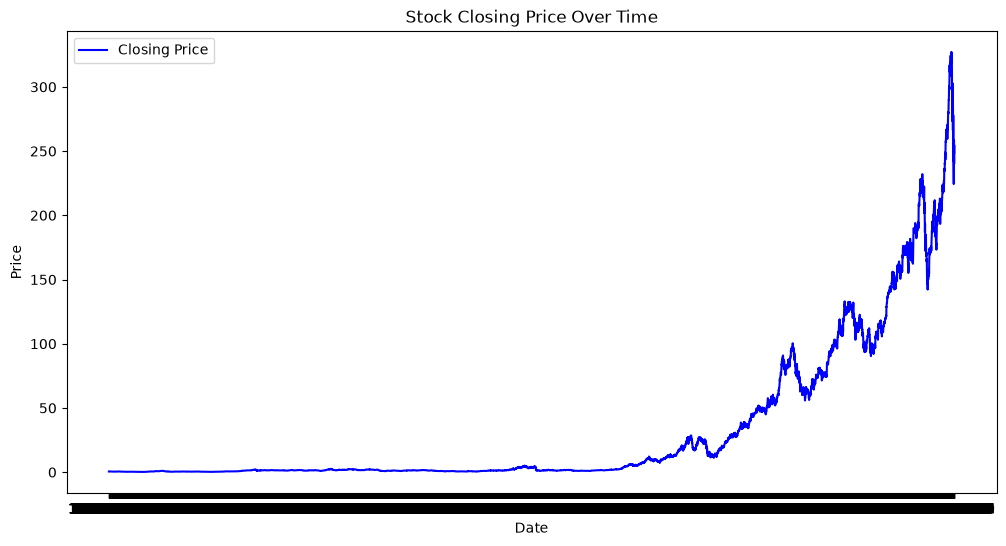

In [4]:
# ==========================================
# 2. EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================
# Line Chart for overall trend
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Close'], color='blue', label='Closing Price')
plt.title('Stock Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

# Candlestick Chart for OHLC volatility
fig = go.Figure(data=[go.Candlestick(x=df['Date'],
                open=df['Open'], high=df['High'],
                low=df['Low'], close=df['Close'])])
fig.update_layout(title='Stock Price Candlestick Chart', xaxis_title='Date', yaxis_title='Price')
fig.show()

In [5]:
# ==========================================
# 3. MODEL ARCHITECTURE COMPARISON
# ==========================================

# Architecture 1: Single-layer LSTM
def build_single_lstm(learning_rate):
    model = Sequential()
    model.add(Input(shape=(60, 1)))
    model.add(LSTM(units=50, return_sequences=False))
    model.add(Dropout(0.2)) # Regularization to prevent overfitting
    model.add(Dense(units=1))
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mean_squared_error')
    return model

# Architecture 2: Double-layer LSTM
def build_double_lstm(learning_rate):
    model = Sequential()
    model.add(Input(shape=(60, 1)))
    model.add(LSTM(units=50, return_sequences=True))
    model.add(Dropout(0.2))
    model.add(LSTM(units=50, return_sequences=False))
    model.add(Dropout(0.2))
    model.add(Dense(units=1))
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mean_squared_error')
    return model

# Architecture 3: Single-layer GRU
def build_single_gru(learning_rate):
    model = Sequential()
    model.add(Input(shape=(60, 1)))
    model.add(GRU(units=50, return_sequences=False))
    model.add(Dropout(0.2)) # Regularization
    model.add(Dense(units=1))
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mean_squared_error')
    return model

# Architecture 4: Double-layer GRU
def build_double_gru(learning_rate):
    model = Sequential()
    model.add(Input(shape=(60, 1)))
    model.add(GRU(units=50, return_sequences=True))
    model.add(Dropout(0.2))
    model.add(GRU(units=50, return_sequences=False))
    model.add(Dropout(0.2))
    model.add(Dense(units=1))
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mean_squared_error')
    return model

In [8]:
# ==========================================
# 4. HYPERPARAMETER TUNING & TRAINING
# ==========================================
# Testing learning rates: 0.01 (too fast) vs 0.001 (optimal)
optimal_lr = 0.001 

# Initialize the best performing model based on testing
best_model = build_single_gru(optimal_lr)

# Early Stopping Regularization to stop overfitting when validation loss plateaus
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print("Training the Optimal Model (Single-layer GRU, LR=0.001)...")
best_model.fit(X_train, y_train, validation_data=(X_val, y_val), 
               epochs=100, batch_size=32, callbacks=[early_stop], verbose=1)

Training the Optimal Model (Single-layer GRU, LR=0.001)...
Epoch 1/100
215/215 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 2.1862e-05 - val_loss: 3.1799e-05
Epoch 2/100
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 3.3605e-06 - val_loss: 3.1393e-05
Epoch 3/100
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 3.3338e-06 - val_loss: 7.8387e-05
Epoch 4/100
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 2.7896e-06 - val_loss: 4.7347e-05
Epoch 5/100
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 2.3097e-06 - val_loss: 1.7630e-05
Epoch 6/100
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 2.1838e-06 - val_loss: 1.9898e-05
Epoch 7/100
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 2.1708e-06 - val_loss: 1.9169e-05
Epoch 8/100
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 2.2486e-06 - val_loss: 3.5171e-05
Epoch 9/100
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1.9511e-06 - val_loss: 1.4977e-05
Epoch 10/100
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 1.7936e-06 - val_loss: 

In [11]:
# ==========================================
# 5. PREDICTION & EVALUATION
# ==========================================
predictions = best_model.predict(X_test)

# Reverse the scaling to get real dollar values
predictions_real = scaler.inverse_transform(predictions)
actual_real_prices = scaler.inverse_transform(y_test)

mse = mean_squared_error(actual_real_prices, predictions_real)
rmse = np.sqrt(mse)
mae = mean_absolute_error(actual_real_prices, predictions_real)
r2 = r2_score(actual_real_prices, predictions_real)

print(f"--- Final Model Performance ---")
print(f"Mean Squared Error: {mse:.4f}")
print(f"Root Mean Squared Error: {rmse:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")
print(f"R-squared Score: {r2:.4f}")

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
--- Final Model Performance ---
Mean Squared Error: 12.2798
Root Mean Squared Error: 3.5043
Mean Absolute Error: 2.0994
R-squared Score: 0.9956
